<a href="https://colab.research.google.com/github/Amri1003/Deep_Learning_Projects/blob/main/ComparingTheoptimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compare optimizers

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adamax, Nadam

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess data
X_train = X_train.reshape((X_train.shape[0], -1)).astype('float32') / 255.0
X_test = X_test.reshape((X_test.shape[0], -1)).astype('float32') / 255.0

# One-hot encode the target labels
y_train = np.eye(10)[y_train]
y_test = np.eye(10)[y_test]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Define model architecture
def create_model():
    model = Sequential()
    model.add(Dense(128, input_dim=784, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    return model

In [ ]:
# Function to train model with different optimizers
def train_model(optimizer):
    model = create_model()
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test), verbose=0)
    return history

In [ ]:

# Optimizers to compare
optimizers = {
    'SGD': SGD(),
    'Adam': Adam(),
    'RMSprop': RMSprop(),
    'Adagrad': Adagrad(),
    'Adadelta': Adadelta(),
    'Adamax': Adamax(),
    'Nadam': Nadam()
}

In [ ]:
# Train models with different optimizers
histories = {}
for name, optimizer in optimizers.items():
    print(f'Training model with {name} optimizer...')
    history = train_model(optimizer)
    histories[name] = history

Training model with SGD optimizer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with Adam optimizer...
Training model with RMSprop optimizer...
Training model with Adagrad optimizer...
Training model with Adadelta optimizer...
Training model with Adamax optimizer...
Training model with Nadam optimizer...


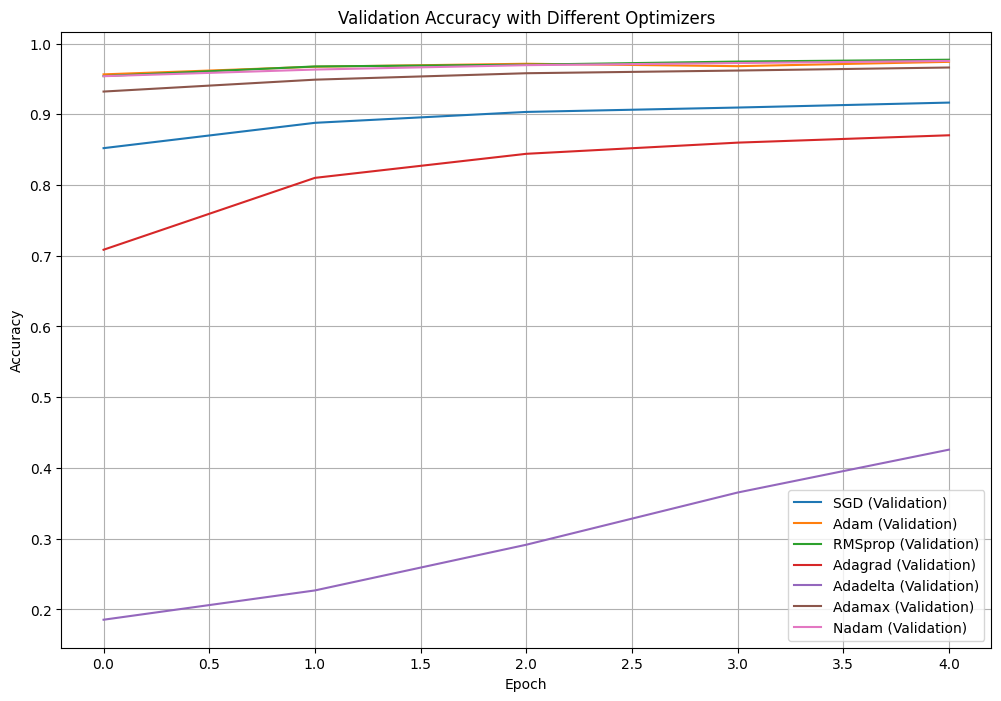

In [ ]:
# Plotting
plt.figure(figsize=(12, 8))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'{name} (Validation)')
plt.title('Validation Accuracy with Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

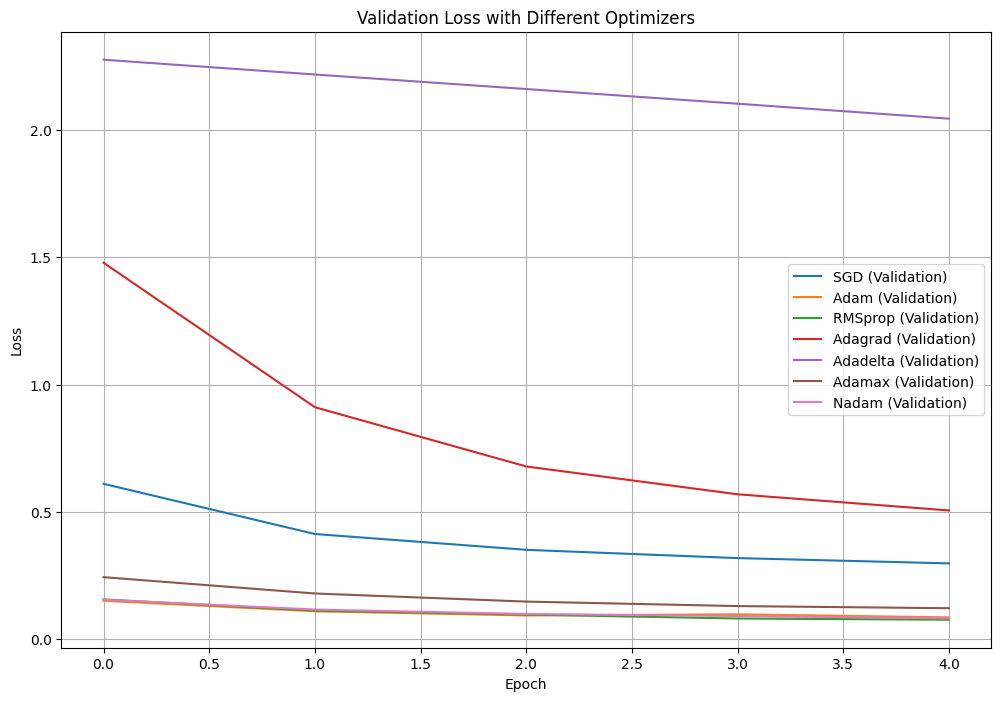

In [ ]:
plt.figure(figsize=(12, 8))
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'{name} (Validation)')
plt.title('Validation Loss with Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# print all model accuracy and loss
for name, history in histories.items():
    print(f'Model: {name}')
    print(f'Validation Accuracy: {history.history["val_accuracy"][-1]}')
    print(f'Validation Loss: {history.history["val_loss"][-1]}')
    print()

Model: SGD
Validation Accuracy: 0.9164999723434448
Validation Loss: 0.29693785309791565

Model: Adam
Validation Accuracy: 0.9740999937057495
Validation Loss: 0.08478762209415436

Model: RMSprop
Validation Accuracy: 0.9771000146865845
Validation Loss: 0.07553718984127045

Model: Adagrad
Validation Accuracy: 0.8702999949455261
Validation Loss: 0.5050007104873657

Model: Adadelta
Validation Accuracy: 0.42590001225471497
Validation Loss: 2.0449442863464355

Model: Adamax
Validation Accuracy: 0.9660999774932861
Validation Loss: 0.12073890119791031

Model: Nadam
Validation Accuracy: 0.9753999710083008
Validation Loss: 0.08105679601430893



# pass optimizer parameters

In [ ]:
model = Sequential()
model.add(Dense(128, input_dim=784, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))


In [ ]:
# Define parameters for Adam optimizer
adam_params = {
    'learning_rate': 0.001,       # learning rate
    'beta_1': 0.9,     # exponential decay rate for the first moment estimates
    'beta_2': 0.999,   # exponential decay rate for the second moment estimates
    'epsilon': 1e-7,   # small constant for numerical stability

}

# Create Adam optimizer with specified parameters
adam_optimizer = Adam(**adam_params)

# Compile model with Adam optimizer
model.compile(optimizer=adam_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9068 - loss: 0.3331 - val_accuracy: 0.9528 - val_loss: 0.1574
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9621 - loss: 0.1297 - val_accuracy: 0.9672 - val_loss: 0.1095
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9729 - loss: 0.0892 - val_accuracy: 0.9715 - val_loss: 0.0955
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9790 - loss: 0.0699 - val_accuracy: 0.9735 - val_loss: 0.0851
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0546 - val_accuracy: 0.9747 - val_loss: 0.0825


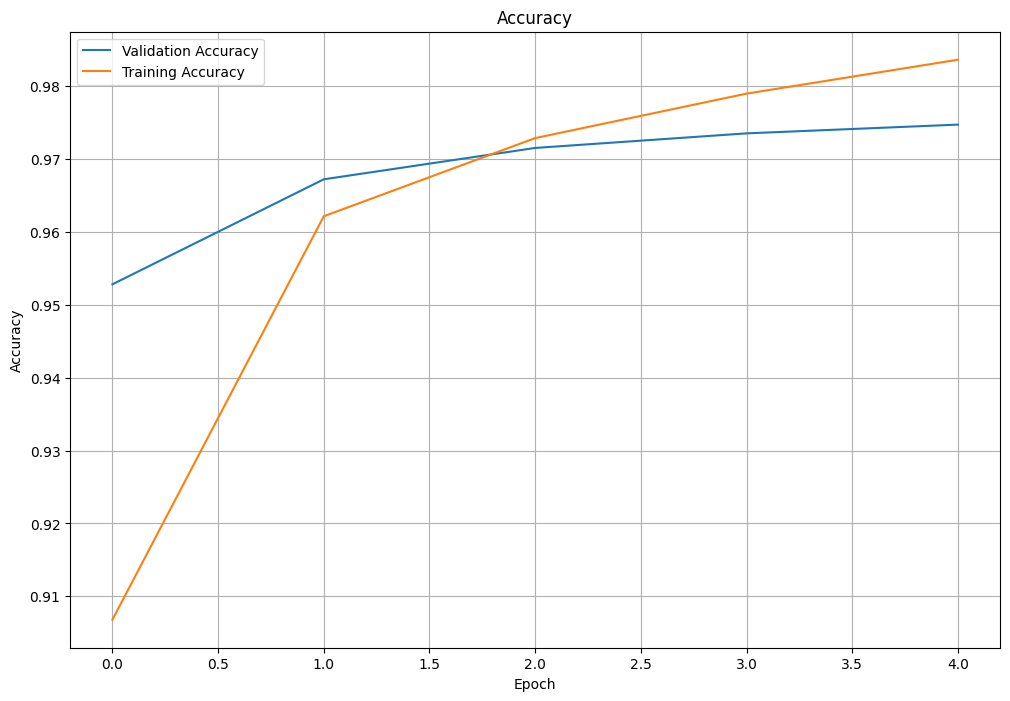

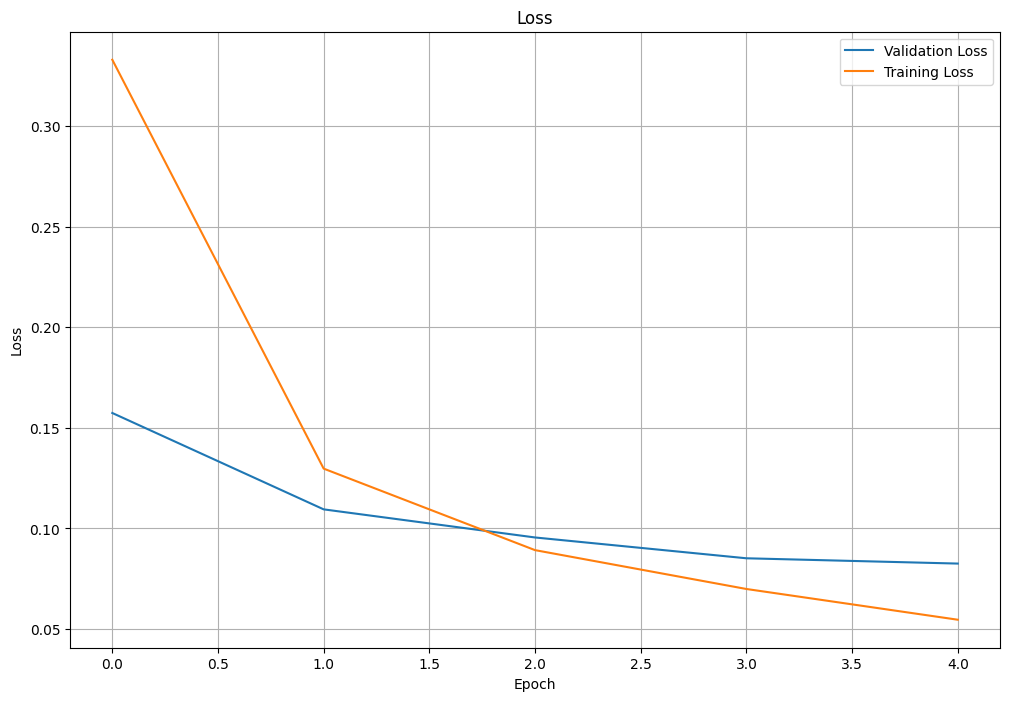

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test), verbose=1)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#sgd with parameters
sgd_params = {
    'learning_rate': 0.01,
    'momentum': 0.9,
    'nesterov': True
}

sgd_optimizer = SGD(**sgd_params)

model.compile(optimizer=sgd_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])